# CodeCloneValidation

In [7]:
from datasets import load_dataset

ds = load_dataset("google/code_x_glue_cc_clone_detection_big_clone_bench")

In [2]:
# Explorer la structure du dataset
print("Splits disponibles:", ds.keys())
print("\nStructure du split 'train':")
print(ds['train'])
print("\nPremier exemple:")
print(ds['train'][0])
print("\nColonnes:", ds['train'].column_names)
print("\nNombre d'exemples - train:", len(ds['train']))
print("Nombre d'exemples - validation:", len(ds['validation']))
print("Nombre d'exemples - test:", len(ds['test']))

Splits disponibles: dict_keys(['train', 'validation', 'test'])

Structure du split 'train':
Dataset({
    features: ['id', 'id1', 'id2', 'func1', 'func2', 'label'],
    num_rows: 901028
})

Premier exemple:
{'id': 0, 'id1': 13988825, 'id2': 8660836, 'func1': '    private void setNodekeyInJsonResponse(String service) throws Exception {\n        String filename = this.baseDirectory + service + ".json";\n        Scanner s = new Scanner(new File(filename));\n        PrintWriter fw = new PrintWriter(new File(filename + ".new"));\n        while (s.hasNextLine()) {\n            fw.println(s.nextLine().replaceAll("NODEKEY", this.key));\n        }\n        s.close();\n        fw.close();\n        (new File(filename + ".new")).renameTo(new File(filename));\n    }\n', 'func2': '    public void transform(String style, String spec, OutputStream out) throws IOException {\n        URL url = new URL(rootURL, spec);\n        InputStream in = new PatchXMLSymbolsStream(new StripDoctypeStream(url.openStre

In [3]:
# Préparation des données: tokenisation et vectorisation avec TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import numpy as np

# Extraire les données pour l'entraînement (on utilise un subset pour la rapidité)
# BigCloneBench contient 'func1', 'func2', et 'label' (0 ou 1 pour clone detection)
train_data = ds['train']
val_data = ds['validation']
test_data = ds['test']

# Limiter à un subset pour l'entraînement rapide (augmenter pour meilleure performance)
SAMPLE_SIZE = 50000
train_subset = train_data.select(range(min(SAMPLE_SIZE, len(train_data))))

print(f"Utilisation de {len(train_subset)} exemples pour l'entraînement")

# Combiner les deux fonctions en une seule représentation
# Stratégie: concaténer func1 et func2 séparés par un token spécial
def combine_funcs(example):
    return example['func1'] + " [SEP] " + example['func2']

X_train_text = [combine_funcs(train_subset[i]) for i in range(len(train_subset))]
y_train = np.array(train_subset['label'])

# Validation set
val_subset = val_data.select(range(min(10000, len(val_data))))
X_val_text = [combine_funcs(val_subset[i]) for i in range(len(val_subset))]
y_val = np.array(val_subset['label'])

# Test set
test_subset = test_data.select(range(min(10000, len(test_data))))
X_test_text = [combine_funcs(test_subset[i]) for i in range(len(test_subset))]
y_test = np.array(test_subset['label'])

print(f"\nTailles des ensembles:")
print(f"Train: {len(X_train_text)} exemples")
print(f"Validation: {len(X_val_text)} exemples")
print(f"Test: {len(X_test_text)} exemples")
print(f"\nDistribution des labels (train): {np.bincount(y_train)}")

Utilisation de 50000 exemples pour l'entraînement

Tailles des ensembles:
Train: 50000 exemples
Validation: 10000 exemples
Test: 10000 exemples

Distribution des labels (train): [24837 25163]

Tailles des ensembles:
Train: 50000 exemples
Validation: 10000 exemples
Test: 10000 exemples

Distribution des labels (train): [24837 25163]


In [4]:
# Vectorisation TF-IDF avec limitation de features
print("Vectorisation TF-IDF en cours...")

# TF-IDF avec paramètres adaptés au code source
vectorizer = TfidfVectorizer(
    max_features=5000,  # Limiter le nombre de features
    min_df=2,           # Ignorer les termes très rares
    max_df=0.95,        # Ignorer les termes trop fréquents
    ngram_range=(1, 2), # Unigrammes et bigrammes
    strip_accents='unicode',
    analyzer='word',
    token_pattern=r'\w{1,}',  # Tokens de 1+ caractères
)

X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_val_tfidf = vectorizer.transform(X_val_text)
X_test_tfidf = vectorizer.transform(X_test_text)

print(f"Dimensions des features TF-IDF: {X_train_tfidf.shape}")
print(f"Densité de la matrice: {X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]):.4f}")

# Convertir en dense pour le réseau de neurones
X_train_dense = X_train_tfidf.toarray()
X_val_dense = X_val_tfidf.toarray()
X_test_dense = X_test_tfidf.toarray()

print("Vectorisation terminée!")

Vectorisation TF-IDF en cours...
Dimensions des features TF-IDF: (50000, 5000)
Densité de la matrice: 0.0299
Dimensions des features TF-IDF: (50000, 5000)
Densité de la matrice: 0.0299
Vectorisation terminée!
Vectorisation terminée!


In [5]:
# Normalisation des données
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_dense)
X_val_scaled = scaler.transform(X_val_dense)
X_test_scaled = scaler.transform(X_test_dense)

print("Normalisation terminée!")
print(f"Shape finale X_train: {X_train_scaled.shape}")
print(f"Shape finale X_val: {X_val_scaled.shape}")
print(f"Shape finale X_test: {X_test_scaled.shape}")

Normalisation terminée!
Shape finale X_train: (50000, 5000)
Shape finale X_val: (10000, 5000)
Shape finale X_test: (10000, 5000)


In [6]:
# Construire un réseau de neurones profond et complexe
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers

print(f"TensorFlow version: {tf.__version__}")

# Architecture profonde avec régularisation
input_dim = X_train_scaled.shape[1]

model = keras.Sequential([
    # Couche d'entrée
    layers.Input(shape=(input_dim,)),
    
    # Bloc 1: Dense + BatchNorm + Dropout
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    
    # Bloc 2
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    
    # Bloc 3
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    # Bloc 4
    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    
    # Bloc 5
    layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    
    # Couche de sortie (classification binaire)
    layers.Dense(1, activation='sigmoid')
], name='ComplexCloneDetector')

# Compiler le modèle
optimizer = keras.optimizers.Adam(learning_rate=0.001)
model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall(), keras.metrics.AUC()]
)

print("\n" + "="*60)
print("ARCHITECTURE DU RÉSEAU DE NEURONES COMPLEXE")
print("="*60)
model.summary()
print("="*60)

TensorFlow version: 2.20.0

ARCHITECTURE DU RÉSEAU DE NEURONES COMPLEXE


Model: "ComplexCloneDetector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     2,560,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,739,073 (10.45 MB)

 Trainable params: 2,737,089 (10.44 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [7]:
# Callbacks pour optimiser l'entraînement
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

model_checkpoint = callbacks.ModelCheckpoint(
    'best_clone_detector.keras',
    monitor='val_auc',
    mode='max',
    save_best_only=True,
    verbose=1
)

tensorboard_callback = callbacks.TensorBoard(
    log_dir='./logs',
    histogram_freq=1
)

callback_list = [early_stopping, reduce_lr, model_checkpoint]

print("Callbacks configurés:")
print("- EarlyStopping (patience=10)")
print("- ReduceLROnPlateau (patience=5)")
print("- ModelCheckpoint (sauvegarde du meilleur modèle)")

Callbacks configurés:
- EarlyStopping (patience=10)
- ReduceLROnPlateau (patience=5)
- ModelCheckpoint (sauvegarde du meilleur modèle)


In [8]:
# Entraîner le modèle
print("\n" + "="*60)
print("DÉBUT DE L'ENTRAÎNEMENT")
print("="*60 + "\n")

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=128,
    callbacks=callback_list,
    verbose=1
)

print("\n" + "="*60)
print("ENTRAÎNEMENT TERMINÉ")
print("="*60)


DÉBUT DE L'ENTRAÎNEMENT

Epoch 1/100
Epoch 1/100
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7289 - auc: 0.8000 - loss: 1.9870 - precision: 0.7438 - recall: 0.7124
Epoch 1: val_auc improved from None to 0.95719, saving model to best_clone_detector.keras

Epoch 1: val_auc improved from None to 0.95719, saving model to best_clone_detector.keras
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.8161 - auc: 0.9032 - loss: 1.6972 - precision: 0.8283 - recall: 0.8006 - val_accuracy: 0.9062 - val_auc: 0.9572 - val_loss: 1.2191 - val_precision: 0.5937 - val_recall: 0.8766 - learning_rate: 0.0010
Epoch 2/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.8161 - auc: 0.9032 - loss: 1.6972 - precision: 0.8283 - recall: 0.8006 - val_accuracy: 0.9062 - val_auc: 0.9572 - val_loss: 1.2191 - val_precision: 0.5937 - val_recall: 0.8766 - learning_rate: 0.0010
Epoch 2/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9084 - auc: 0.9710 - loss: 1.0787 - precision: 0

In [9]:
# Évaluation sur l'ensemble de test
print("\n" + "="*60)
print("ÉVALUATION SUR L'ENSEMBLE DE TEST")
print("="*60 + "\n")

test_results = model.evaluate(X_test_scaled, y_test, verbose=1)

print("\n" + "-"*60)
print("RÉSULTATS FINAUX SUR LE TEST SET:")
print("-"*60)
print(f"Loss: {test_results[0]:.4f}")
print(f"Accuracy: {test_results[1]:.4f}")
print(f"Precision: {test_results[2]:.4f}")
print(f"Recall: {test_results[3]:.4f}")
print(f"AUC: {test_results[4]:.4f}")
print("-"*60)

# Calculer F1-score
precision = test_results[2]
recall = test_results[3]
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
print(f"F1-Score: {f1_score:.4f}")
print("="*60)


ÉVALUATION SUR L'ENSEMBLE DE TEST

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9638 - auc: 0.9654 - loss: 0.2141 - precision: 0.8476 - recall: 0.8938

------------------------------------------------------------
RÉSULTATS FINAUX SUR LE TEST SET:
------------------------------------------------------------
Loss: 0.2141
Accuracy: 0.9638
Precision: 0.8476
Recall: 0.8938
AUC: 0.9654
------------------------------------------------------------
F1-Score: 0.8701
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9638 - auc: 0.9654 - loss: 0.2141 - precision: 0.8476 - recall: 0.8938

------------------------------------------------------------
RÉSULTATS FINAUX SUR LE TEST SET:
------------------------------------------------------------
Loss: 0.2141
Accuracy: 0.9638
Precision: 0.8476
Recall: 0.8938
AUC: 0.9654
------------------------------------------------------------
F1-Score: 0.8701


Clés disponibles dans l'historique: ['accuracy', 'auc', 'loss', 'precision', 'recall', 'val_accuracy', 'val_auc', 'val_loss', 'val_precision', 'val_recall', 'learning_rate']


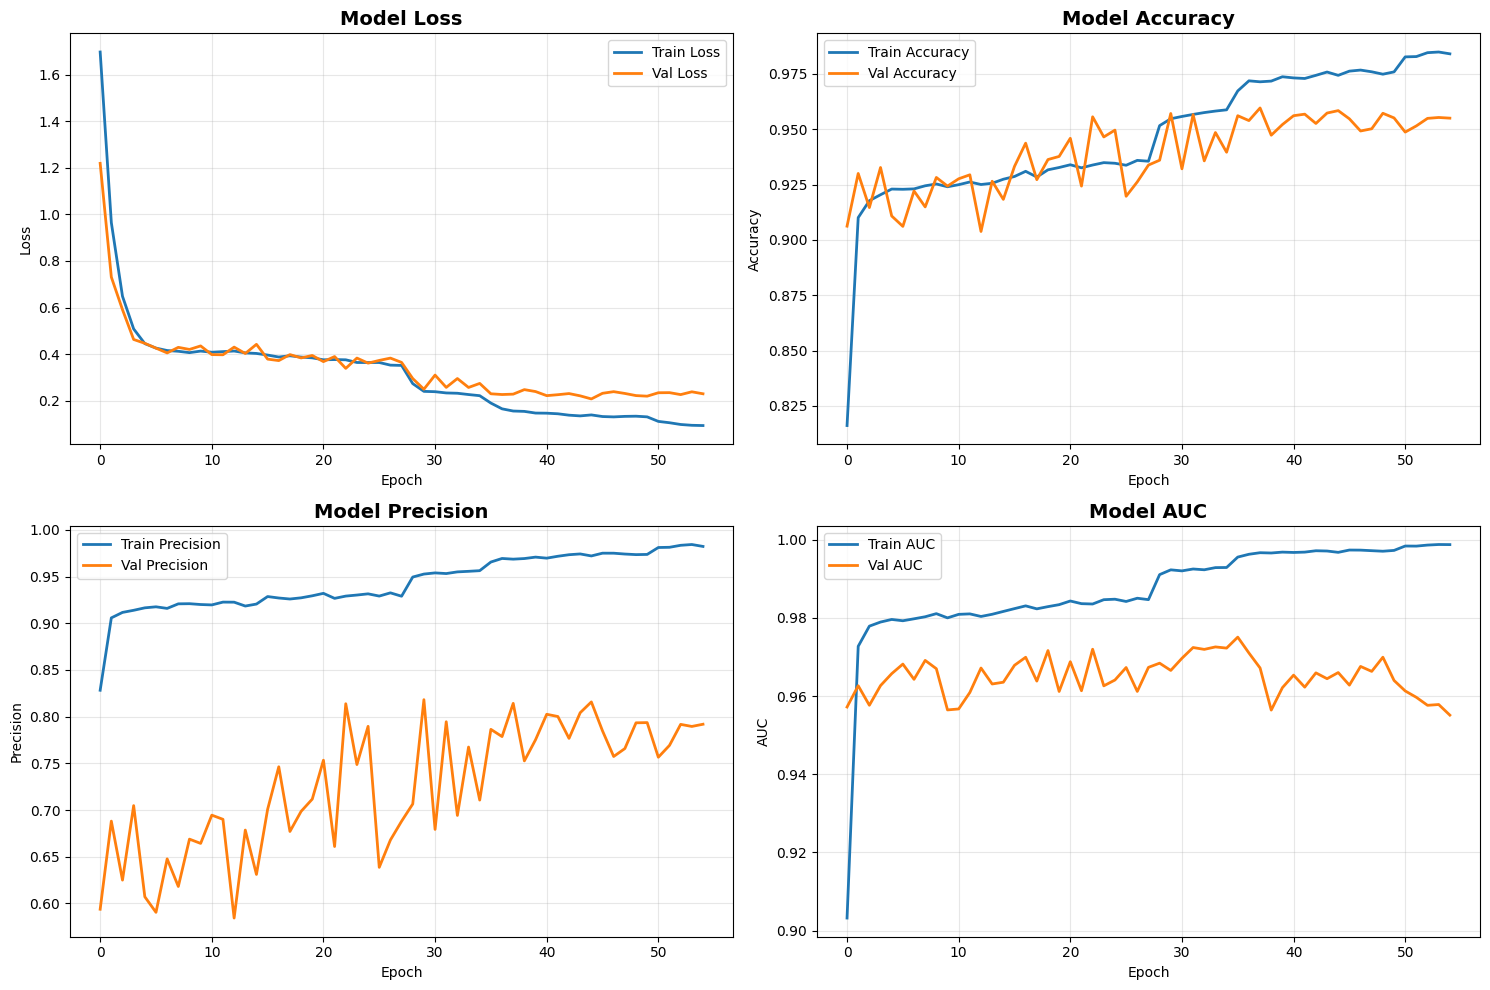

Courbes d'apprentissage affichées!


In [13]:
# Visualisation des courbes d'apprentissage
import matplotlib.pyplot as plt

# Afficher les clés disponibles dans l'historique
print("Clés disponibles dans l'historique:", list(history.history.keys()))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0, 0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0, 0].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0, 1].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0, 1].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Precision (chercher la bonne clé)
precision_key = [k for k in history.history.keys() if 'precision' in k.lower() and not k.startswith('val')][0]
val_precision_key = [k for k in history.history.keys() if 'precision' in k.lower() and k.startswith('val')][0]
axes[1, 0].plot(history.history[precision_key], label='Train Precision', linewidth=2)
axes[1, 0].plot(history.history[val_precision_key], label='Val Precision', linewidth=2)
axes[1, 0].set_title('Model Precision', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# AUC (chercher la bonne clé)
auc_key = [k for k in history.history.keys() if 'auc' in k.lower() and not k.startswith('val')][0]
val_auc_key = [k for k in history.history.keys() if 'auc' in k.lower() and k.startswith('val')][0]
axes[1, 1].plot(history.history[auc_key], label='Train AUC', linewidth=2)
axes[1, 1].plot(history.history[val_auc_key], label='Val AUC', linewidth=2)
axes[1, 1].set_title('Model AUC', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('AUC')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Courbes d'apprentissage affichées!")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


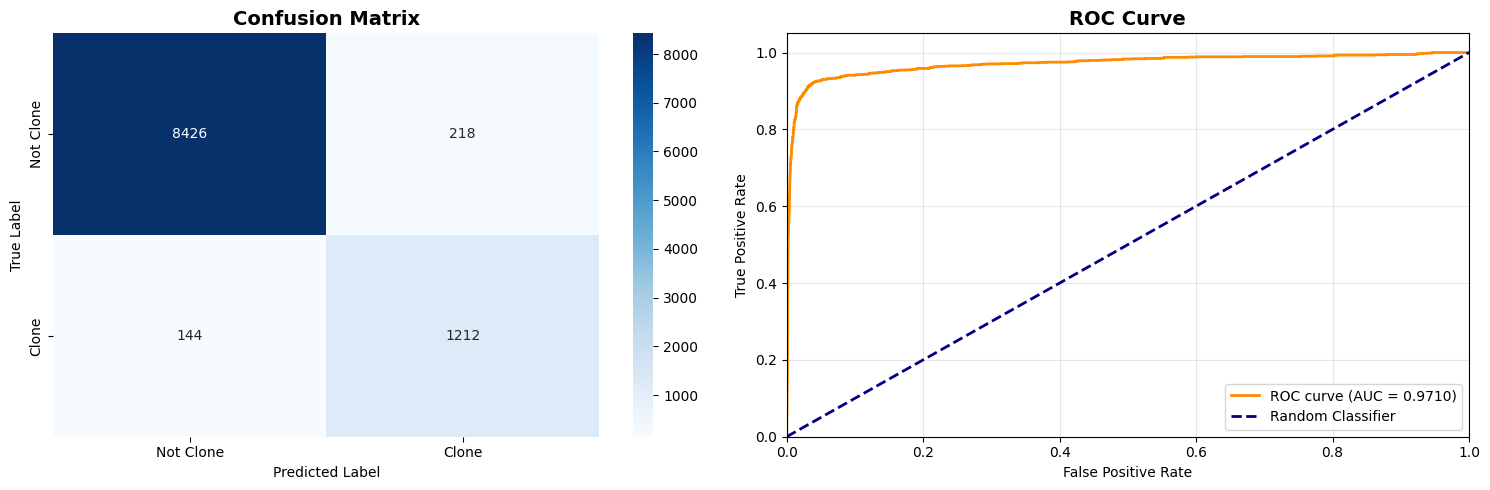


RAPPORT DE CLASSIFICATION DÉTAILLÉ
              precision    recall  f1-score   support

   Not Clone       0.98      0.97      0.98      8644
       Clone       0.85      0.89      0.87      1356

    accuracy                           0.96     10000
   macro avg       0.92      0.93      0.92     10000
weighted avg       0.96      0.96      0.96     10000



In [14]:
# Matrice de confusion et rapport de classification détaillé
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns

# Prédictions sur le test set
y_pred_proba = model.predict(X_test_scaled).flatten()
y_pred = (y_pred_proba > 0.5).astype(int)

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Heatmap de la matrice de confusion
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Not Clone', 'Clone'],
            yticklabels=['Not Clone', 'Clone'])
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Rapport de classification détaillé
print("\n" + "="*60)
print("RAPPORT DE CLASSIFICATION DÉTAILLÉ")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Not Clone', 'Clone']))
print("="*60)

In [ ]:
# Analyse des prédictions - exemples de clones détectés et non détectés
print("\n" + "="*60)
print("ANALYSE DES PRÉDICTIONS")
print("="*60)

# Trouver quelques exemples de vrais positifs, vrais négatifs, faux positifs, faux négatifs
true_positives = np.where((y_test == 1) & (y_pred == 1))[0]
true_negatives = np.where((y_test == 0) & (y_pred == 0))[0]
false_positives = np.where((y_test == 0) & (y_pred == 1))[0]
false_negatives = np.where((y_test == 1) & (y_pred == 0))[0]

print(f"\nNombre de vrais positifs: {len(true_positives)}")
print(f"Nombre de vrais négatifs: {len(true_negatives)}")
print(f"Nombre de faux positifs: {len(false_positives)}")
print(f"Nombre de faux négatifs: {len(false_negatives)}")

# Afficher un exemple de chaque catégorie (FONCTIONS COMPLÈTES)
if len(true_positives) > 0:
    idx = true_positives[0]
    print(f"\n{'='*60}")
    print("VRAI POSITIF (Clone correctement détecté)")
    print(f"{'='*60}")
    print(f"Probabilité: {y_pred_proba[idx]:.4f}")
    print(f"\n--- Fonction 1 ---")
    print(test_subset[idx]['func1'])
    print(f"\n--- Fonction 2 ---")
    print(test_subset[idx]['func2'])
    print("="*60)

if len(false_negatives) > 0:
    idx = false_negatives[0]
    print(f"\n{'='*60}")
    print("FAUX NÉGATIF (Clone manqué)")
    print(f"{'='*60}")
    print(f"Probabilité: {y_pred_proba[idx]:.4f}")
    print(f"\n--- Fonction 1 ---")
    print(test_subset[idx]['func1'])
    print(f"\n--- Fonction 2 ---")
    print(test_subset[idx]['func2'])
    print("="*60)

if len(false_positives) > 0:
    idx = false_positives[0]
    print(f"\n{'='*60}")
    print("FAUX POSITIF (Non-clone détecté à tort comme clone)")
    print(f"{'='*60}")
    print(f"Probabilité: {y_pred_proba[idx]:.4f}")
    print(f"\n--- Fonction 1 ---")
    print(test_subset[idx]['func1'])
    print(f"\n--- Fonction 2 ---")
    print(test_subset[idx]['func2'])
    print("="*60)

print("\n" + "="*60)


ANALYSE DES PRÉDICTIONS

Nombre de vrais positifs: 1212
Nombre de vrais négatifs: 8426
Nombre de faux positifs: 218
Nombre de faux négatifs: 144

--- VRAI POSITIF (Clone correctement détecté) ---
Probabilité: 0.9995
Func1:     public static void copyFile(File source, File dest) throws IOException {
        FileChannel in ...
Func2:     public static void copyFile(File from, File to) throws IOException {
        if (from.isDirector...

--- FAUX NÉGATIF (Clone manqué) ---
Probabilité: 0.0055
Func1:     public static void main(String[] args) throws Exception {
        String st = "http://www.kmzlin...
Func2:     public static void main(String[] args) {
        try {
            boolean readExp = Utils.getFl...

